# Scope emissions, intensity, and reduction analysis

This notebook uses the cached Trucost–LSEG–FactSet matched panel to compare Scope 1, Scope 2 location- and market-based, and Scope 3 upstream and downstream emissions. It then groups companies by the direction of their intensity change and examines policy adoption at one- to three-year horizons. A separate section studies Scope 3 upstream **absolute** emissions up to six years after adoption.

Run from top to bottom with the working directory set to `notebooks/`. Figures use levels or direct percentage reductions; selected fixed-effects models use log changes. These are descriptive associations, not causal effects.


## 1. Setup

Input paths, analysis years, emissions fields, and output folder.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
MATCHED_PANEL_PATH = PROJECT_ROOT / "data/processed/trucost_lseg_factset_matched_2015_2025.csv.gz"
FACTSET_ROOT = PROJECT_ROOT / "data/raw/FactSet"
OUTPUT_DIR = PROJECT_ROOT / "data/outputs/dataset_readers/scope_emissions_intensity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2015 is retained only as the lag for 2016 reductions.
PANEL_YEARS = set(range(2015, 2025))
OUTCOME_YEARS = set(range(2016, 2025))
COMPANY_ID = "trucost_company_id"
SCOPE_COLUMNS = {
    "Scope 1": "scope_1_emissions",
    "Scope 2 location-based": "scope_2_location_based_emissions",
    #"Scope 2 market-based": "scope_2_market_based_emissions",
    "Scope 3 upstream": "scope_3_upstream_emissions",
    #"Scope 3 downstream": "scope_3_downstream_emissions",
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)


## 2. Matched company-year panel

Keep one Trucost company-year and attach FactSet sector labels.


In [3]:
if not MATCHED_PANEL_PATH.exists():
    raise FileNotFoundError(f"Matched panel not found: {MATCHED_PANEL_PATH}")

base = pd.read_csv(MATCHED_PANEL_PATH, compression="gzip", low_memory=False)
base["year"] = pd.to_numeric(base["year"], errors="coerce").astype("Int64")
base = base[base["year"].isin(PANEL_YEARS)].copy()
required_columns = {"year", COMPANY_ID, "factset_entity_id", "trucost_revenue", "esg_score", *SCOPE_COLUMNS.values()}
missing_columns = sorted(required_columns.difference(base.columns))
if missing_columns:
    raise KeyError(f"Matched panel is missing: {missing_columns}")

# One row per Trucost company-year, using match quality only to resolve duplicates.
base["_lseg_match_score"] = pd.to_numeric(base.get("lseg_name_score"), errors="coerce")
base["_factset_match_score"] = pd.to_numeric(base.get("factset_name_score"), errors="coerce")
base["_isin_sort"] = base.get("isin", pd.Series("", index=base.index)).astype("string").fillna("")
base = (
    base.sort_values(
        [COMPANY_ID, "year", "_lseg_match_score", "_factset_match_score", "_isin_sort"],
        ascending=[True, True, False, False, True],
        na_position="last",
    )
    .drop_duplicates([COMPANY_ID, "year"], keep="first")
    .reset_index(drop=True)
)

# Attach FactSet sector names.
entity_sector = pd.read_csv(
    FACTSET_ROOT / "sym_entity_v1_full_12328/sym_entity_sector.txt",
    sep="|", quotechar='"', dtype=str,
    usecols=["FACTSET_ENTITY_ID", "INDUSTRY_CODE", "SECTOR_CODE"],
)
sector_map = pd.read_csv(
    FACTSET_ROOT / "ref_hub_v2_full_3565/factset_sector_map.txt",
    sep="|", quotechar='"', dtype=str,
)
industry_map = pd.read_csv(
    FACTSET_ROOT / "ref_hub_v2_full_3565/factset_industry_map.txt",
    sep="|", quotechar='"', dtype=str,
).rename(columns={"FACTSET_SECTOR_CODE": "SECTOR_CODE_FROM_INDUSTRY"})
entity_sector = entity_sector.merge(
    industry_map, left_on="INDUSTRY_CODE", right_on="FACTSET_INDUSTRY_CODE", how="left"
)
entity_sector["SECTOR_CODE_FINAL"] = entity_sector["SECTOR_CODE"].where(
    entity_sector["SECTOR_CODE"].notna() & entity_sector["SECTOR_CODE"].ne(""),
    entity_sector["SECTOR_CODE_FROM_INDUSTRY"],
)
sector_lookup = (
    entity_sector.merge(
        sector_map, left_on="SECTOR_CODE_FINAL", right_on="FACTSET_SECTOR_CODE", how="left"
    )[["FACTSET_ENTITY_ID", "FACTSET_SECTOR_DESC"]]
    .rename(columns={"FACTSET_SECTOR_DESC": "SECTOR_DESC"})
    .drop_duplicates("FACTSET_ENTITY_ID")
)
base = base.merge(
    sector_lookup, left_on="factset_entity_id", right_on="FACTSET_ENTITY_ID", how="left"
).drop(columns=["FACTSET_ENTITY_ID", "_lseg_match_score", "_factset_match_score", "_isin_sort"])

print(f"Scope panel: {len(base):,} company-years; {base[COMPANY_ID].nunique():,} companies")
print(f"Sector coverage: {base['SECTOR_DESC'].notna().mean():.1%}")


Scope panel: 89,228 company-years; 12,680 companies
Sector coverage: 97.7%


## 3. Emissions-intensity levels

ESG-complete company-years in 2016–2024.


In [4]:
# The plotted intensity sample uses ESG-complete company-years in 2016--2024.
intensity_panel = base.copy()
intensity_panel["esg_score"] = pd.to_numeric(intensity_panel["esg_score"], errors="coerce")
intensity_panel = intensity_panel[
    intensity_panel["year"].isin(OUTCOME_YEARS) & intensity_panel["esg_score"].notna()
].copy()
intensity_panel["trucost_revenue"] = pd.to_numeric(intensity_panel["trucost_revenue"], errors="coerce")

emission_column_to_scope = {column: scope for scope, column in SCOPE_COLUMNS.items()}
intensity_long = intensity_panel.melt(
    id_vars=["year", COMPANY_ID, "SECTOR_DESC", "trucost_revenue"],
    value_vars=list(SCOPE_COLUMNS.values()),
    var_name="emission_column", value_name="emissions_tco2e",
)
intensity_long["scope"] = intensity_long["emission_column"].map(emission_column_to_scope)
intensity_long["emissions_tco2e"] = pd.to_numeric(intensity_long["emissions_tco2e"], errors="coerce")
intensity_long["emissions_intensity"] = intensity_long["emissions_tco2e"].div(intensity_long["trucost_revenue"])
intensity_long = intensity_long[
    intensity_long["trucost_revenue"].gt(0)
    & intensity_long["emissions_tco2e"].ge(0)
    & intensity_long["emissions_intensity"].ge(0)
].copy()

intensity_sector_year = (
    intensity_long.dropna(subset=["SECTOR_DESC"])
    .groupby(["year", "SECTOR_DESC", "scope"], as_index=False)
    .agg(
        mean_emissions =("emissions_tco2e","mean"),
        mean_intensity=("emissions_intensity", "mean"),
        median_intensity=("emissions_intensity", "median"),
        sd_intensity=("emissions_intensity", "std"),
        observations=("emissions_intensity", "size"),
    )
)
intensity_sector_year["se_intensity"] = intensity_sector_year["sd_intensity"] / np.sqrt(intensity_sector_year["observations"])
#display(intensity_sector_year.sort_values(["scope", "year", "SECTOR_DESC"]))


### Sector trends in mean intensity


In [ ]:
def plot_sector_year_lines(data, value_column, title, y_label, output_filename):
    sectors = sorted(data["SECTOR_DESC"].dropna().unique())
    scopes = sorted(data["scope"].dropna().unique())
    palette = dict(zip(sectors, sns.color_palette("tab20", n_colors=len(sectors))))
    n_columns = 3
    n_rows = int(np.ceil(len(scopes) / n_columns))
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(19, 5 * n_rows), sharex=True, sharey=False)
    legend_handles, legend_labels = None, None

    for index, (ax, scope) in enumerate(zip(np.ravel(axes), scopes)):
        subset = data[data["scope"].eq(scope)].copy()
        sns.lineplot(
            data=subset, x="year", y=value_column, hue="SECTOR_DESC",
            hue_order=sectors, palette=palette, marker="o", estimator=None,
            errorbar=None, legend=index == 0, ax=ax,
        )
        if index == 0 and ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(scope)
        ax.set_xlabel("Outcome year")
        ax.set_ylabel(y_label)
        ax.set_xticks(sorted(OUTCOME_YEARS))
        ax.tick_params(axis="x", rotation=45)

    for ax in np.ravel(axes)[len(scopes):]:
        ax.set_visible(False)
    if legend_handles:
        fig.legend(legend_handles, legend_labels, title="FactSet sector", loc="center left", bbox_to_anchor=(0.82, 0.5), fontsize=8)
    #fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    output_path = OUTPUT_DIR / output_filename
    fig.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")

plot_sector_year_lines(
    intensity_sector_year,
    value_column="mean_intensity",
    title="Mean scope-specific emissions intensity by FactSet sector",
    y_label="Mean emissions intensity (tCO2e / Trucost revenue unit)",
    output_filename="Mean scope-specific emissions intensity by FactSet sector.pdf",
)


## 4. Consecutive-year emissions reductions

Compute absolute and revenue-intensity reductions before restricting the outcome sample.


In [ ]:
# Build within-company annual absolute-emissions and intensity changes before restricting to outcome years.
reduction_panel = base.copy().sort_values([COMPANY_ID, "year"]).reset_index(drop=True)
reduction_panel["trucost_revenue"] = pd.to_numeric(reduction_panel["trucost_revenue"], errors="coerce")
reduction_panel["esg_score"] = pd.to_numeric(reduction_panel["esg_score"], errors="coerce")
previous_year = reduction_panel.groupby(COMPANY_ID)["year"].shift(1)
previous_revenue = reduction_panel.groupby(COMPANY_ID)["trucost_revenue"].shift(1)

LOG_REDUCTION_OUTCOMES = []  # Use only in regressions.
PCT_REDUCTION_OUTCOMES = []  # Use in every descriptive table and figure.
PCT_OUTCOME_TO_SCOPE = {}
PCT_OUTCOME_TO_BASIS = {}
for label, column in SCOPE_COLUMNS.items():
    scope_key = label.lower().replace(" ", "_").replace("-", "_")
    current_emissions = pd.to_numeric(reduction_panel[column], errors="coerce")
    previous_emissions = pd.to_numeric(reduction_panel.groupby(COMPANY_ID)[column].shift(1), errors="coerce")
    current_intensity = current_emissions.div(reduction_panel["trucost_revenue"])
    previous_intensity = previous_emissions.div(previous_revenue)
    valid_absolute_pct_pair = (
        current_emissions.ge(0) & previous_emissions.gt(0)
        & reduction_panel["year"].eq(previous_year + 1)
    )
    valid_intensity_pct_pair = (
        current_emissions.ge(0) & previous_emissions.gt(0)
        & reduction_panel["trucost_revenue"].gt(0) & previous_revenue.gt(0)
        & current_intensity.ge(0) & previous_intensity.gt(0)
        & reduction_panel["year"].eq(previous_year + 1)
    )
    reduction_definitions = {
        "Absolute emissions": (
            current_emissions, previous_emissions, valid_absolute_pct_pair,
        ),
        "Emissions intensity": (
            current_intensity, previous_intensity, valid_intensity_pct_pair,
        ),
    }
    for basis, (current_value, previous_value, valid_pct_pair) in reduction_definitions.items():
        basis_key = basis.lower().replace(" ", "_")
        valid_log_pair = valid_pct_pair & current_value.gt(0)
        log_outcome = f"{scope_key}_{basis_key}_log_reduction"
        pct_outcome = f"{scope_key}_{basis_key}_pct_reduction"
        reduction_panel[log_outcome] = (
            np.log(previous_value.where(valid_log_pair))
            - np.log(current_value.where(valid_log_pair))
        )
        reduction_panel[pct_outcome] = 100 * (
            1 - current_value.where(valid_pct_pair) / previous_value.where(valid_pct_pair)
        )
        LOG_REDUCTION_OUTCOMES.append(log_outcome)
        PCT_REDUCTION_OUTCOMES.append(pct_outcome)
        PCT_OUTCOME_TO_SCOPE[pct_outcome] = label
        PCT_OUTCOME_TO_BASIS[pct_outcome] = basis

# Restrict the descriptive and regression samples to ESG-complete outcome years.
reduction_panel = reduction_panel[
    reduction_panel["year"].isin(OUTCOME_YEARS) & reduction_panel["esg_score"].notna()
].copy()
reduction_long = reduction_panel.melt(
    id_vars=["year", COMPANY_ID, "SECTOR_DESC"],
    value_vars=PCT_REDUCTION_OUTCOMES,
    var_name="reduction_measure", value_name="pct_reduction",
).dropna(subset=["pct_reduction"])
reduction_long["scope"] = reduction_long["reduction_measure"].map(PCT_OUTCOME_TO_SCOPE)
reduction_long["reduction_basis"] = reduction_long["reduction_measure"].map(PCT_OUTCOME_TO_BASIS)
reduction_long = reduction_long.drop(columns="reduction_measure")

# Extreme percentage changes are almost always driven by a very small prior-year
# intensity or revenue denominator.  Keep the raw panel for auditability, then
# remove the outer 1% in each tail within every scope and reduction basis.
# Change these quantiles (or set REMOVE_REDUCTION_OUTLIERS=False) for sensitivity checks.
REMOVE_REDUCTION_OUTLIERS = True
REDUCTION_OUTLIER_QUANTILES = (0.01, 0.99)
reduction_long_raw = reduction_long.copy()
reduction_outlier_bounds = (
    reduction_long_raw.groupby(["scope", "reduction_basis"])["pct_reduction"]
    .quantile(list(REDUCTION_OUTLIER_QUANTILES)).unstack()
    .rename(columns={REDUCTION_OUTLIER_QUANTILES[0]: "lower_bound", REDUCTION_OUTLIER_QUANTILES[1]: "upper_bound"})
    .reset_index()
)
reduction_long = reduction_long_raw.merge(
    reduction_outlier_bounds, on=["scope", "reduction_basis"], how="left", validate="many_to_one"
)
reduction_long["is_reduction_outlier"] = (
    reduction_long["pct_reduction"].lt(reduction_long["lower_bound"])
    | reduction_long["pct_reduction"].gt(reduction_long["upper_bound"])
)
reduction_outlier_summary = (
    reduction_long.groupby(["scope", "reduction_basis"], as_index=False)
    .agg(
        lower_bound=("lower_bound", "first"), upper_bound=("upper_bound", "first"),
        observations_before=("pct_reduction", "size"),
        observations_removed=("is_reduction_outlier", "sum"),
    )
)
reduction_outlier_summary["observations_after"] = (
    reduction_outlier_summary["observations_before"] - reduction_outlier_summary["observations_removed"]
)
display(reduction_outlier_summary)
if REMOVE_REDUCTION_OUTLIERS:
    reduction_long = reduction_long.loc[~reduction_long["is_reduction_outlier"]].copy()
reduction_long = reduction_long.drop(columns=["lower_bound", "upper_bound"])

reduction_sector_year = (
    reduction_long.dropna(subset=["SECTOR_DESC"])
    .groupby(["year", "SECTOR_DESC", "scope", "reduction_basis"], as_index=False)
    .agg(
        mean_pct_reduction=("pct_reduction", "mean"),
        median_pct_reduction=("pct_reduction", "median"),
        observations=("pct_reduction", "size"),
        companies=(COMPANY_ID, "nunique"),
    )
)
#display(reduction_sector_year.sort_values(["reduction_basis", "scope", "year", "SECTOR_DESC"]))


### Plot sector-year reductions


In [ ]:
for reduction_basis, output_filename in {
    "Absolute emissions": "all_sector_pct_absolute_emissions_reduction_by_year.pdf",
    "Emissions intensity": "all_sector_pct_intensity_reduction_by_year.pdf",
}.items():
    plot_sector_year_lines(
        reduction_sector_year[reduction_sector_year["reduction_basis"].eq(reduction_basis)],
        value_column="mean_pct_reduction",
        title=f"Mean annual {reduction_basis.lower()} reduction by FactSet sector",
        y_label=f"Mean {reduction_basis.lower()} reduction (%)",
        output_filename=output_filename,
    )


### Log outcomes reserved for regression models


In [ ]:
# These variables are intentionally reserved for regression models only. Apply
# the same outcome-specific tail screen so descriptive and regression samples agree.
regression_panel = reduction_panel[["year", COMPANY_ID, "SECTOR_DESC", *LOG_REDUCTION_OUTCOMES]].copy()
for pct_outcome in PCT_REDUCTION_OUTCOMES:
    log_outcome = pct_outcome.replace("_pct_reduction", "_log_reduction")
    retained_keys = reduction_long.loc[
        reduction_long["scope"].eq(PCT_OUTCOME_TO_SCOPE[pct_outcome])
        & reduction_long["reduction_basis"].eq(PCT_OUTCOME_TO_BASIS[pct_outcome]),
        ["year", COMPANY_ID],
    ].drop_duplicates()
    retained_index = pd.MultiIndex.from_frame(retained_keys)
    regression_index = pd.MultiIndex.from_frame(regression_panel[["year", COMPANY_ID]])
    regression_panel[log_outcome] = regression_panel[log_outcome].where(regression_index.isin(retained_index))
print("Log outcomes retained for regression only:", LOG_REDUCTION_OUTCOMES)


## 5. Direction of intensity change

Separate positive reductions, no change, and increases; retain a two-group version for later comparisons.


C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\T

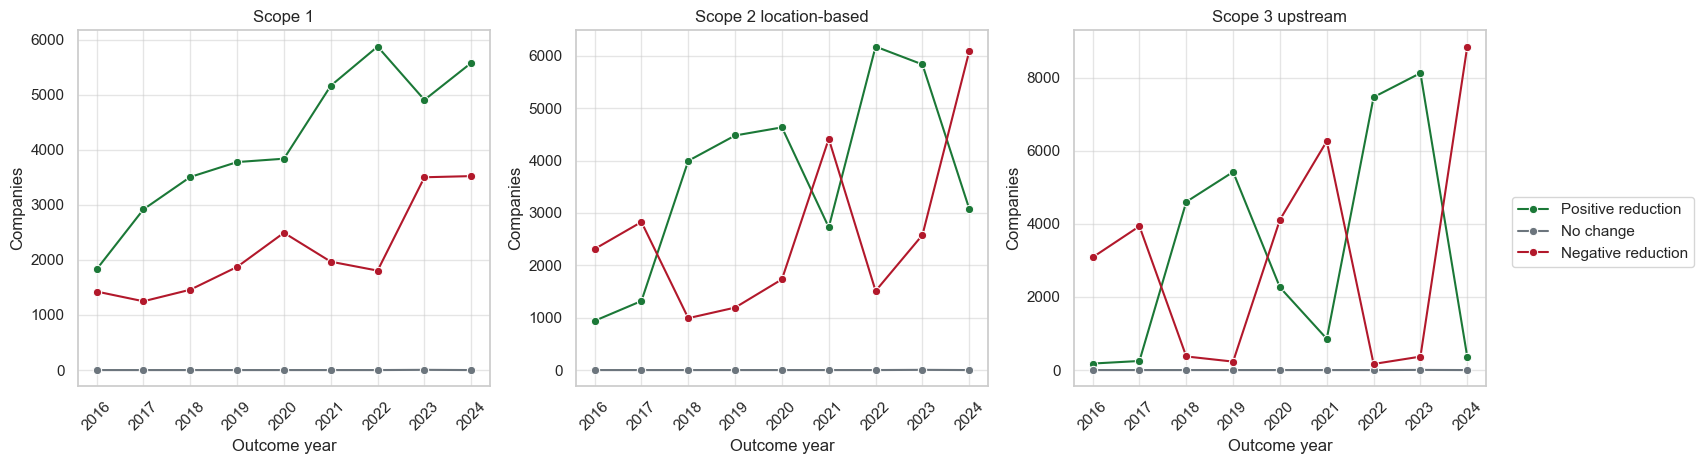

Saved: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\scope_emissions_intensity\Companies by annual emissions-intensity change direction.pdf


C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\TRACE3Code\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\scelik\Desktop\T

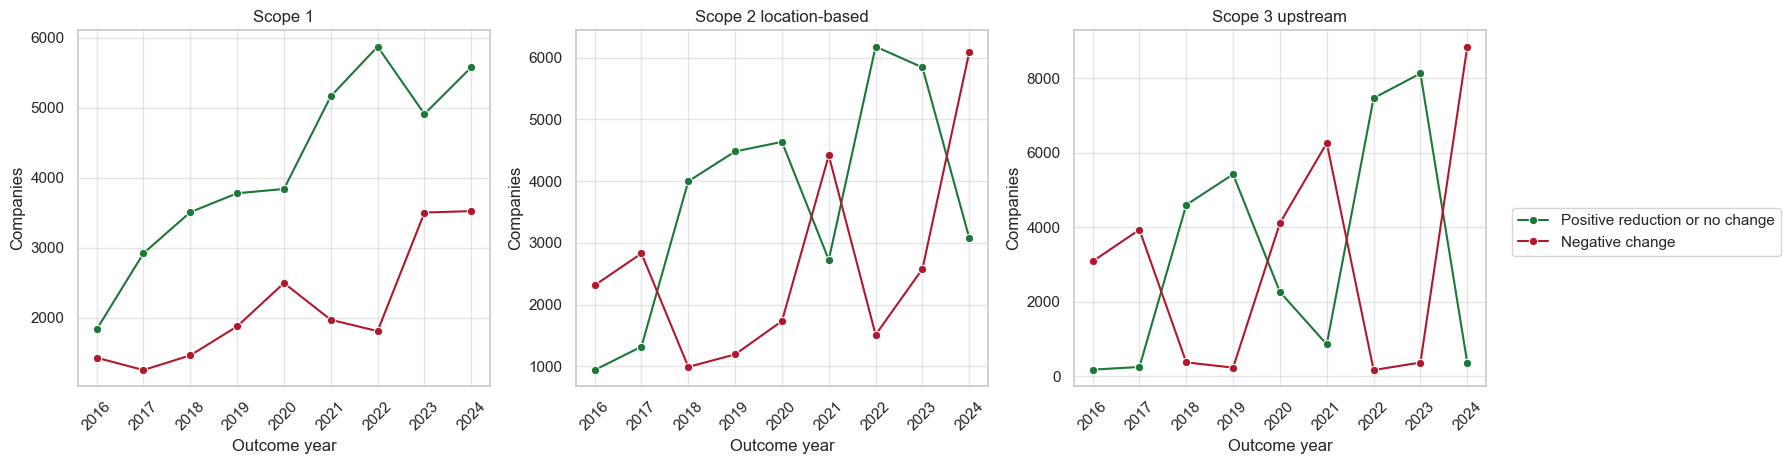

Saved: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\scope_emissions_intensity\Two-sample classification of annual emissions-intensity change.pdf


In [8]:
# A very small tolerance prevents numerical round-off from being labelled a change.
INTENSITY_NO_CHANGE_TOLERANCE = 1e-10  # percentage points
DIRECTION_ORDER = [
    "Positive reduction",
    "No change",
    "Negative reduction",
]
ANALYSIS_SAMPLE_ORDER = [
    "Positive reduction or no change",
    "Negative change",
]

# One row is a company-year-scope observation.  Keep this tidy panel for all
# follow-on comparisons; it can be joined back to base on [year, COMPANY_ID].
intensity_change_group_panel = reduction_long.loc[
    reduction_long["reduction_basis"].eq("Emissions intensity")
].copy()
intensity_change_group_panel["reduction_direction"] = np.select(
    [
        intensity_change_group_panel["pct_reduction"].gt(INTENSITY_NO_CHANGE_TOLERANCE),
        intensity_change_group_panel["pct_reduction"].lt(-INTENSITY_NO_CHANGE_TOLERANCE),
    ],
    ["Positive reduction", "Negative reduction"],
    default="No change",
)
# This is the requested two-sample grouping: no worsening (including exactly
# unchanged intensity) versus an intensity increase.
intensity_change_group_panel["analysis_sample"] = np.where(
    intensity_change_group_panel["pct_reduction"].ge(-INTENSITY_NO_CHANGE_TOLERANCE),
    "Positive reduction or no change",
    "Negative change",
)

def complete_company_counts(data, group_column, category_order):
    """Return a zero-filled company count for every outcome year and scope."""
    scopes = sorted(data["scope"].dropna().unique())
    grid = pd.MultiIndex.from_product(
        [sorted(OUTCOME_YEARS), scopes, category_order],
        names=["year", "scope", group_column],
    )
    counts = (
        data.groupby(["year", "scope", group_column], observed=True)
        .agg(
            company_years=(COMPANY_ID, "size"),
            companies=(COMPANY_ID, "nunique"),
        )
        .reindex(grid, fill_value=0)
        .reset_index()
    )
    return counts

yearly_intensity_direction_counts = complete_company_counts(
    intensity_change_group_panel, "reduction_direction", DIRECTION_ORDER
)
yearly_intensity_analysis_sample_counts = complete_company_counts(
    intensity_change_group_panel, "analysis_sample", ANALYSIS_SAMPLE_ORDER
)

# display(
#     yearly_intensity_direction_counts.pivot(
#         index=["year", "scope"], columns="reduction_direction", values="companies"
#     ).reindex(columns=DIRECTION_ORDER).fillna(0).astype(int)
# )
# display(
#     yearly_intensity_analysis_sample_counts.pivot(
#         index=["year", "scope"], columns="analysis_sample", values="companies"
#     ).reindex(columns=ANALYSIS_SAMPLE_ORDER).fillna(0).astype(int)
# )

def plot_intensity_change_counts(data, group_column, category_order, palette, title, output_filename):
    scopes = sorted(data["scope"].dropna().unique())
    n_columns = 3
    n_rows = int(np.ceil(len(scopes) / n_columns))
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(18, 4.8 * n_rows), sharex=True, facecolor="white"
    )
    legend_handles, legend_labels = None, None

    for index, (ax, scope) in enumerate(zip(np.ravel(axes), scopes)):
        ax.set_facecolor("white")
        subset = data[data["scope"].eq(scope)]
        sns.lineplot(
            data=subset, x="year", y="companies", hue=group_column,
            hue_order=category_order, palette=palette, marker="o",
            estimator=None, errorbar=None, legend=index == 0, ax=ax,
        )
        if index == 0 and ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()
        ax.set_title(scope)
        ax.set_xlabel("Outcome year")
        ax.set_ylabel("Companies")
        ax.set_xticks(sorted(OUTCOME_YEARS))
        ax.tick_params(axis="x", rotation=45)

    for ax in np.ravel(axes)[len(scopes):]:
        ax.set_visible(False)
    if legend_handles:
        fig.legend(
            legend_handles, legend_labels, loc="center left", bbox_to_anchor=(0.84, 0.5)
        )
    #fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    output_path = OUTPUT_DIR / output_filename
    fig.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")

plot_intensity_change_counts(
    yearly_intensity_direction_counts,
    group_column="reduction_direction",
    category_order=DIRECTION_ORDER,
    palette={
        "Positive reduction": "#1b7837",
        "No change": "#6c757d",
        "Negative reduction": "#b2182b",
    },
    title="Companies by annual emissions-intensity change direction",
    output_filename="Companies by annual emissions-intensity change direction.pdf",
)
plot_intensity_change_counts(
    yearly_intensity_analysis_sample_counts,
    group_column="analysis_sample",
    category_order=ANALYSIS_SAMPLE_ORDER,
    palette={
        "Positive reduction or no change": "#1b7837",
        "Negative change": "#b2182b",
    },
    title="Two-sample classification of annual emissions-intensity change",
    output_filename="Two-sample classification of annual emissions-intensity change.pdf",
)


## 6. Policy events and later intensity outcomes

Policy adoption means an observed 0-to-1 change; missing policy fields are not zero.


### Policy taxonomy and available fields


In [ ]:
POLICY_CATEGORIES = {
    "Policy on emissions": ["policy_emissions"],
    "Environmental material sourcing": ["environmental_materials_sourcing"],
    "Energy and carbon": [ "policy_energy_efficiency", "policy_clean_energy", "target_energy_efficiency", "internal_carbon_policy"], #"policy_emissions",
    "Environmental supply chain": ["policy_environmental_supply_chain", "environmental_supply_chain_monitoring", "environmental_supply_chain_management", ],
    "Product design and circularity": ["policy_sustainable_packaging", "take_back_recycling", "eco_design"],
    #"Hybrid vehicles": ["hybrid_vehicles"],
    "Governance and reporting": ["sustainability_reporting", "iso_14000_or_ems"],
}
POLICY_CATEGORY_PREFIX = {
    "Policy on emissions" : "policy_emissions",
    "Environmental material sourcing": "environmental_materials_sourcing",
    "Energy and carbon": "energy_carbon",
    #'Hybrid vehicles': 'hybrid_vehicles',
    "Environmental supply chain": "supply_chain",
    "Product design and circularity": "product_circularity",
    "Governance and reporting": "governance_reporting",
}

LSEG_POLICY_FIELDS = [
    "policy_emissions", "policy_energy_efficiency",
    "policy_environmental_supply_chain", "policy_sustainable_packaging",
    "policy_clean_energy", "take_back_recycling", #"hybrid_vehicles",
    "eco_design", "sustainability_reporting", "target_energy_efficiency",
    "internal_carbon_policy", "environmental_supply_chain_monitoring",
    "environmental_supply_chain_management",
    "environmental_materials_sourcing", "iso_14000_or_ems",
]

def as_binary_policy_flag(values):
    numeric = pd.to_numeric(values, errors="coerce")
    result = pd.Series(np.nan, index=values.index, dtype=float)
    result.loc[numeric.isin([0, 1])] = numeric.loc[numeric.isin([0, 1])]
    text = values.astype("string").str.strip().str.casefold()
    result.loc[text.isin({"true", "yes", "y", "1"})] = 1.0
    result.loc[text.isin({"false", "no", "n", "0"})] = 0.0
    return result

AVAILABLE_POLICY_FIELDS = [field for field in LSEG_POLICY_FIELDS if field in base.columns]
MISSING_POLICY_FIELDS = [field for field in LSEG_POLICY_FIELDS if field not in base.columns]
print(f"Policy fields available: {len(AVAILABLE_POLICY_FIELDS)} / {len(LSEG_POLICY_FIELDS)}")
print("Not available in this cache:", MISSING_POLICY_FIELDS)
# Validate the mapping as a true one-to-one assignment. A set comparison alone
# would miss duplicate assignments because sets discard repeated field names.
policy_category_mapping = pd.DataFrame([
    {"policy_category": category, "policy": field}
    for category, fields in POLICY_CATEGORIES.items()
    for field in fields
])
assignment_counts = policy_category_mapping["policy"].value_counts()
duplicate_assignments = assignment_counts[assignment_counts.gt(1)].index.tolist()
unassigned_policies = sorted(set(LSEG_POLICY_FIELDS) - set(assignment_counts.index))
unknown_policies = sorted(set(assignment_counts.index) - set(LSEG_POLICY_FIELDS))
missing_prefixes = sorted(set(POLICY_CATEGORIES) - set(POLICY_CATEGORY_PREFIX))
duplicate_prefixes = (
    pd.Series(POLICY_CATEGORY_PREFIX).value_counts().loc[lambda values: values.gt(1)].index.tolist()
)
if duplicate_assignments or unassigned_policies or unknown_policies or missing_prefixes or duplicate_prefixes:
    raise ValueError(
        "Invalid policy categorization. "
        f"Duplicates: {duplicate_assignments}; unassigned: {unassigned_policies}; "
        f"unknown: {unknown_policies}; missing prefixes: {missing_prefixes}; "
        f"duplicate prefixes: {duplicate_prefixes}."
    )
AVAILABLE_POLICY_CATEGORIES = {
    category: [field for field in fields if field in AVAILABLE_POLICY_FIELDS]
    for category, fields in POLICY_CATEGORIES.items()
}
# Do not create empty category rows when an LSEG field is unavailable.
AVAILABLE_POLICY_CATEGORIES = {
    category: fields for category, fields in AVAILABLE_POLICY_CATEGORIES.items() if fields
}
policy_category_mapping["available_in_panel"] = policy_category_mapping["policy"].isin(AVAILABLE_POLICY_FIELDS)
display(policy_category_mapping.sort_values(["policy_category", "policy"]))
print("Available policy fields by category:", {key: len(value) for key, value in AVAILABLE_POLICY_CATEGORIES.items()})


### Within-company policy transitions


In [ ]:
# Calculate annual policy and ESG events before restricting the outcome sample.
policy_events = base[["year", COMPANY_ID, "esg_score", *AVAILABLE_POLICY_FIELDS]].copy()
policy_events = policy_events.sort_values([COMPANY_ID, "year"]).reset_index(drop=True)
policy_events["esg_score"] = pd.to_numeric(policy_events["esg_score"], errors="coerce")
policy_flags = policy_events[AVAILABLE_POLICY_FIELDS].apply(as_binary_policy_flag)
previous_flags = policy_flags.groupby(policy_events[COMPANY_ID]).shift(1)
previous_event_year = policy_events.groupby(COMPANY_ID)["year"].shift(1)
consecutive_event_year = policy_events["year"].eq(previous_event_year + 1)
policy_pair_observed = policy_flags.notna() & previous_flags.notna()
policy_pair_observed.loc[~consecutive_event_year, :] = False
new_policy_flags = policy_flags.eq(1) & previous_flags.eq(0) & policy_pair_observed
policy_events["policies_compared"] = policy_pair_observed.sum(axis=1)
policy_events["new_policy_count"] = new_policy_flags.sum(axis=1).where(
    policy_events["policies_compared"].gt(0)
)
policy_events["new_policy_rate"] = policy_events["new_policy_count"].div(
    policy_events["policies_compared"].replace(0, np.nan)
)

# Construct category-specific adoption counts. Missing policy fields remain
# missing, so a non-disclosure is never interpreted as no adoption.
POLICY_CATEGORY_EVENT_COLUMNS = []
for category, fields in AVAILABLE_POLICY_CATEGORIES.items():
    prefix = POLICY_CATEGORY_PREFIX[category]
    compared_column = f"{prefix}_policies_compared"
    count_column = f"{prefix}_new_policy_count"
    rate_column = f"{prefix}_new_policy_rate"
    policy_events[compared_column] = policy_pair_observed[fields].sum(axis=1)
    policy_events[count_column] = new_policy_flags[fields].sum(axis=1).where(
        policy_events[compared_column].gt(0)
    )
    policy_events[rate_column] = policy_events[count_column].div(
        policy_events[compared_column].replace(0, np.nan)
    )
    POLICY_CATEGORY_EVENT_COLUMNS.extend([compared_column, count_column, rate_column])
previous_esg = policy_events.groupby(COMPANY_ID)["esg_score"].shift(1)
policy_events["esg_score_change"] = (policy_events["esg_score"] - previous_esg).where(
    consecutive_event_year & policy_events["esg_score"].notna() & previous_esg.notna()
)


### Align adoption with outcome years

Lag 2 compares the outcome with the adoption-year baseline.


In [ ]:
# One row per company-year-scope: this is the positive/no-change versus negative
# company tag used for all subsequent policy comparisons.
company_intensity_tags = intensity_change_group_panel[[
    "year", COMPANY_ID, "scope", "reduction_direction", "analysis_sample", "pct_reduction"
]].copy()
company_intensity_tags["positive_intensity_reduction"] = company_intensity_tags["reduction_direction"].eq("Positive reduction")
company_intensity_tags["negative_intensity_change"] = company_intensity_tags["reduction_direction"].eq("Negative reduction")
company_intensity_tags["positive_or_no_change"] = company_intensity_tags["analysis_sample"].eq("Positive reduction or no change")
display(company_intensity_tags.head())

# Merge policy events by calendar year. Lag 1 means adoption in year t-1 and
# intensity reduction in year t; row position is never used as a lag.
policy_lag_analysis = reduction_panel.copy()
EVENT_COLUMNS = [
    "new_policy_count", "policies_compared", "new_policy_rate", "esg_score_change",
    *POLICY_CATEGORY_EVENT_COLUMNS,
]
for event_lag in [0, 1, 2,3]:
    lagged_events = policy_events[[COMPANY_ID, "year", *EVENT_COLUMNS]].copy()
    lagged_events["year"] = lagged_events["year"] + event_lag
    lagged_events = lagged_events.rename(columns={
        column: f"{column}_lag{event_lag}" for column in EVENT_COLUMNS
    })
    policy_lag_analysis = policy_lag_analysis.merge(
        lagged_events, on=[COMPANY_ID, "year"], how="left", validate="one_to_one"
    )

# Keep both direct percentages (for the event tables) and log reductions (for a
# later regression). This selects only emissions-intensity, not absolute, outcomes.
scope_to_pct_outcome = {
    PCT_OUTCOME_TO_SCOPE[outcome]: outcome
    for outcome in PCT_REDUCTION_OUTCOMES
    if PCT_OUTCOME_TO_BASIS[outcome] == "Emissions intensity"
}
event_id_columns = ["year", COMPANY_ID, "SECTOR_DESC"] + [
    f"{column}_lag{lag}" for lag in [0, 1, 2, 3] for column in EVENT_COLUMNS
]
event_parts = []
for scope, pct_outcome in scope_to_pct_outcome.items():
    log_outcome = pct_outcome.replace("_pct_reduction", "_log_reduction")
    part = policy_lag_analysis[event_id_columns].copy()
    part["scope"] = scope
    part["pct_reduction"] = pd.to_numeric(policy_lag_analysis[pct_outcome], errors="coerce")
    part["log_reduction"] = pd.to_numeric(policy_lag_analysis[log_outcome], errors="coerce")
    event_parts.append(part)
policy_effect_long = pd.concat(event_parts, ignore_index=True).merge(
    company_intensity_tags.drop(columns="pct_reduction"),
    on=["year", COMPANY_ID, "scope"], how="left", validate="one_to_one"
)

# Event-study outcome: compare the outcome-year intensity with intensity in the
# year of policy adoption. Thus, at lag 2, I_(adoption + 2) is compared with
# I_adoption; this is not an annual I_t versus I_(t-1) change.
intensity_level_parts = []
for scope, emissions_column in SCOPE_COLUMNS.items():
    intensity_levels = base[[COMPANY_ID, "year", emissions_column, "trucost_revenue"]].copy()
    intensity_levels["intensity"] = pd.to_numeric(
        intensity_levels[emissions_column], errors="coerce"
    ).div(pd.to_numeric(intensity_levels["trucost_revenue"], errors="coerce"))
    intensity_level_parts.append(
        intensity_levels[[COMPANY_ID, "year", "intensity"]].assign(scope=scope)
    )
intensity_levels_long = pd.concat(intensity_level_parts, ignore_index=True)
policy_effect_long = policy_effect_long.merge(
    intensity_levels_long.rename(columns={"intensity": "outcome_year_intensity"}),
    on=[COMPANY_ID, "year", "scope"], how="left", validate="many_to_one"
)
for event_lag in [0, 1, 2, 3]:
    adoption_year_intensity = intensity_levels_long.copy()
    adoption_year_intensity["year"] = adoption_year_intensity["year"] + event_lag
    baseline_column = f"policy_year_intensity_lag{event_lag}"
    outcome_column = f"policy_year_pct_reduction_lag{event_lag}"
    adoption_year_intensity = adoption_year_intensity.rename(
        columns={"intensity": baseline_column}
    )
    policy_effect_long = policy_effect_long.merge(
        adoption_year_intensity, on=[COMPANY_ID, "year", "scope"],
        how="left", validate="many_to_one"
    )
    valid_policy_year_pair = (
        policy_effect_long["outcome_year_intensity"].ge(0)
        & policy_effect_long[baseline_column].gt(0)
    )
    policy_effect_long[outcome_column] = 100 * (
        1 - policy_effect_long["outcome_year_intensity"].where(valid_policy_year_pair)
        / policy_effect_long[baseline_column].where(valid_policy_year_pair)
    )

# Apply the same transparent tail screen to cumulative event-study outcomes.
# Bounds are estimated separately by scope and horizon, because a three-year
# cumulative change naturally has a wider distribution than a one-year change.
REMOVE_POLICY_EVENT_OUTLIERS = True
POLICY_EVENT_OUTLIER_QUANTILES = (0.01, 0.99)
policy_event_outlier_summaries = []
for event_lag in [0, 1, 2, 3]:
    outcome_column = f"policy_year_pct_reduction_lag{event_lag}"
    lower_bound = policy_effect_long.groupby("scope")[outcome_column].transform(
        lambda values: values.quantile(POLICY_EVENT_OUTLIER_QUANTILES[0])
    )
    upper_bound = policy_effect_long.groupby("scope")[outcome_column].transform(
        lambda values: values.quantile(POLICY_EVENT_OUTLIER_QUANTILES[1])
    )
    outlier_column = f"{outcome_column}_is_outlier"
    policy_effect_long[outlier_column] = (
        policy_effect_long[outcome_column].notna()
        & (policy_effect_long[outcome_column].lt(lower_bound) | policy_effect_long[outcome_column].gt(upper_bound))
    )
    policy_event_outlier_summaries.append(
        policy_effect_long.groupby("scope", as_index=False).agg(
            observations_before=(outcome_column, "count"),
            observations_removed=(outlier_column, "sum"),
        ).assign(policy_event_lag=event_lag)
    )
policy_event_outlier_summary = pd.concat(policy_event_outlier_summaries, ignore_index=True)
policy_event_outlier_summary["observations_after"] = (
    policy_event_outlier_summary["observations_before"] - policy_event_outlier_summary["observations_removed"]
)
display(policy_event_outlier_summary)


### Policy counts, categories, and descriptive associations


In [ ]:
# Total new-policy count groups: 0, up to 2, up to 4, and 5 or more.
POLICY_GROUPS = ["0", "1-2", "3-4", "5+"]
POLICY_GROUP_BINS = [-0.1, 0.1, 2.1, 4.1, np.inf]
policy_summaries, policy_correlations = [], []
policy_category_summaries, policy_category_correlations = [], []
esg_summaries, esg_correlations = [], []
from scipy.stats import spearmanr

def spearman_test(frame, predictor):
    """Spearman association of a predictor with the event-study reduction."""
    pairs = frame[["pct_reduction", predictor]].dropna()
    if len(pairs) < 3 or pairs["pct_reduction"].nunique() < 2 or pairs[predictor].nunique() < 2:
        return {"observations": len(pairs), "spearman_rho": np.nan, "p_value": np.nan}
    result = spearmanr(pairs[predictor], pairs["pct_reduction"])
    return {
        "observations": len(pairs),
        "spearman_rho": result.statistic,
        "p_value": result.pvalue,
    }

for event_lag in [0, 1, 2, 3]:
    policy_column = f"new_policy_count_lag{event_lag}"
    compared_column = f"policies_compared_lag{event_lag}"
    outcome_column = f"policy_year_pct_reduction_lag{event_lag}"
    event_data = policy_effect_long.loc[
        policy_effect_long[outcome_column].notna()
        & (~policy_effect_long[f"{outcome_column}_is_outlier"] | (not REMOVE_POLICY_EVENT_OUTLIERS))
    ].copy()
    event_data["pct_reduction"] = event_data[outcome_column]
    policy_data = event_data.loc[
        event_data[compared_column].gt(0)
        & event_data[policy_column].notna()
    ].copy()
    policy_data["policy_adoption_group"] = pd.cut(
        policy_data[policy_column], POLICY_GROUP_BINS, labels=POLICY_GROUPS
    )
    policy_summaries.append(
        policy_data.groupby(["scope", "policy_adoption_group"], observed=True)
        .agg(
            companies=(COMPANY_ID, "nunique"),
            mean_pct_reduction=("pct_reduction", "mean"),
            median_pct_reduction=("pct_reduction", "median"),
            positive_or_no_change_pct=("analysis_sample", lambda values: 100 * values.eq("Positive reduction or no change").mean()),
        ).reset_index().assign(policy_event_lag=event_lag)
    )
    for scope, group in policy_data.groupby("scope"):
        test_result = spearman_test(group, policy_column)
        policy_correlations.append({
            "scope": scope, "policy_event_lag": event_lag,
            **test_result,
        })

    # Repeat the adoption comparison for each substantive policy category.
    for policy_category, fields in AVAILABLE_POLICY_CATEGORIES.items():
        prefix = POLICY_CATEGORY_PREFIX[policy_category]
        category_count = f"{prefix}_new_policy_count_lag{event_lag}"
        category_compared = f"{prefix}_policies_compared_lag{event_lag}"
        category_data = event_data.loc[
            event_data[category_compared].gt(0)
            & event_data[category_count].notna()
        ].copy()
        category_data["policy_adoption_group"] = pd.cut(
            category_data[category_count], POLICY_GROUP_BINS, labels=POLICY_GROUPS
        )
        # Retain sector-specific estimates and add a separately calculated
        # all-sector estimate. The latter is not a sum of sector statistics.
        aggregation = {
            "companies": (COMPANY_ID, "nunique"),
            "mean_pct_reduction": ("pct_reduction", "mean"),
            "median_pct_reduction": ("pct_reduction", "median"),
            "positive_or_no_change_pct": ("analysis_sample", lambda values: 100 * values.eq("Positive reduction or no change").mean()),
        }
        sector_summary = (
            category_data.dropna(subset=["SECTOR_DESC"])
            .groupby(["SECTOR_DESC", "scope", "policy_adoption_group"], observed=True)
            .agg(**aggregation).reset_index()
        )
        all_sector_summary = (
            category_data.assign(SECTOR_DESC="All sectors")
            .groupby(["SECTOR_DESC", "scope", "policy_adoption_group"], observed=True)
            .agg(**aggregation).reset_index()
        )
        policy_category_summaries.append(
            pd.concat([all_sector_summary, sector_summary], ignore_index=True)
            .assign(policy_category=policy_category, policy_event_lag=event_lag)
        )
        correlation_data = pd.concat([
            category_data.assign(SECTOR_DESC="All sectors"),
            category_data.dropna(subset=["SECTOR_DESC"]),
        ], ignore_index=True)
        for (sector_name, scope), group in correlation_data.groupby(["SECTOR_DESC", "scope"]):
            test_result = spearman_test(group, category_count)
            policy_category_correlations.append({
                "SECTOR_DESC": sector_name, "scope": scope,
                "policy_category": policy_category, "policy_event_lag": event_lag,
                **test_result,
            })

    esg_column = f"esg_score_change_lag{event_lag}"
    esg_data = event_data.dropna(subset=[esg_column]).copy()
    esg_data["esg_change_group"] = np.select(
        [esg_data[esg_column].gt(1e-10), esg_data[esg_column].lt(-1e-10)],
        ["ESG increased", "ESG decreased"], default="No ESG change"
    )
    esg_summaries.append(
        esg_data.groupby(["scope", "esg_change_group"], observed=True)
        .agg(
            companies=(COMPANY_ID, "nunique"),
            mean_esg_score_change=(esg_column, "mean"),
            mean_pct_reduction=("pct_reduction", "mean"),
            median_pct_reduction=("pct_reduction", "median"),
            positive_or_no_change_pct=("analysis_sample", lambda values: 100 * values.eq("Positive reduction or no change").mean()),
        ).reset_index().assign(esg_change_lag=event_lag)
    )
    for scope, group in esg_data.groupby("scope"):
        test_result = spearman_test(group, esg_column)
        esg_correlations.append({
            "scope": scope, "esg_change_lag": event_lag,
            **test_result,
        })

policy_lag_summary = pd.concat(policy_summaries, ignore_index=True)
policy_lag_correlations = pd.DataFrame(policy_correlations)
policy_category_lag_summary = pd.concat(policy_category_summaries, ignore_index=True)
policy_category_lag_correlations = pd.DataFrame(policy_category_correlations)
esg_lag_summary = pd.concat(esg_summaries, ignore_index=True)
esg_lag_correlations = pd.DataFrame(esg_correlations)

# print("Policy results: lags 1, 2, and 3 are one, two, and three years after policy adoption.")
# display(policy_lag_summary.sort_values(["policy_event_lag", "scope", "policy_adoption_group"]))
# print("Policy-count Spearman correlations with intensity reduction:")
# display(policy_lag_correlations.sort_values(["policy_event_lag", "scope"]))
# print("Policy-category results:")
# display(policy_category_lag_summary.sort_values(["SECTOR_DESC", "policy_event_lag", "policy_category", "scope", "policy_adoption_group"]))
# print("Policy-category Spearman correlations with intensity reduction:")
# display(policy_category_lag_correlations.sort_values(["policy_event_lag", "policy_category", "scope"]))
# print("ESG-change results:")
# display(esg_lag_summary.sort_values(["esg_change_lag", "scope", "esg_change_group"]))
# display(esg_lag_correlations.sort_values(["esg_change_lag", "scope"]))

# Direct answer for firms adopting one-to-two or three-to-four policies: their
# reduction and positive/no-change share one to three years later, by emissions scope.
two_to_four_policy_lagged_results = policy_lag_summary.loc[
    policy_lag_summary["policy_event_lag"].isin([1, 2, 3])
    & policy_lag_summary["policy_adoption_group"].isin(["1-2", "3-4"])
].copy()
display(two_to_four_policy_lagged_results)

rho_matrix = policy_lag_correlations.pivot(
    index="scope", columns="policy_event_lag", values="spearman_rho"
).reindex(columns=[1, 2, 3])
fig, ax = plt.subplots(figsize=(7, 3.5), facecolor="white")
ax.set_facecolor("white")
sns.heatmap(rho_matrix, cmap="RdBu_r", center=0, vmin=-0.25, vmax=0.25,
            annot=True, fmt=".2f", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("New-policy adoption and cumulative emissions-intensity reduction")
ax.set_xlabel("Years after policy-adoption year")
ax.set_ylabel("Emissions scope")
plt.tight_layout()
policy_heatmap_path = OUTPUT_DIR / "New-policy adoption and emissions-intensity reduction.pdf"
fig.savefig(policy_heatmap_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {policy_heatmap_path}")


### Distribution and weighted means


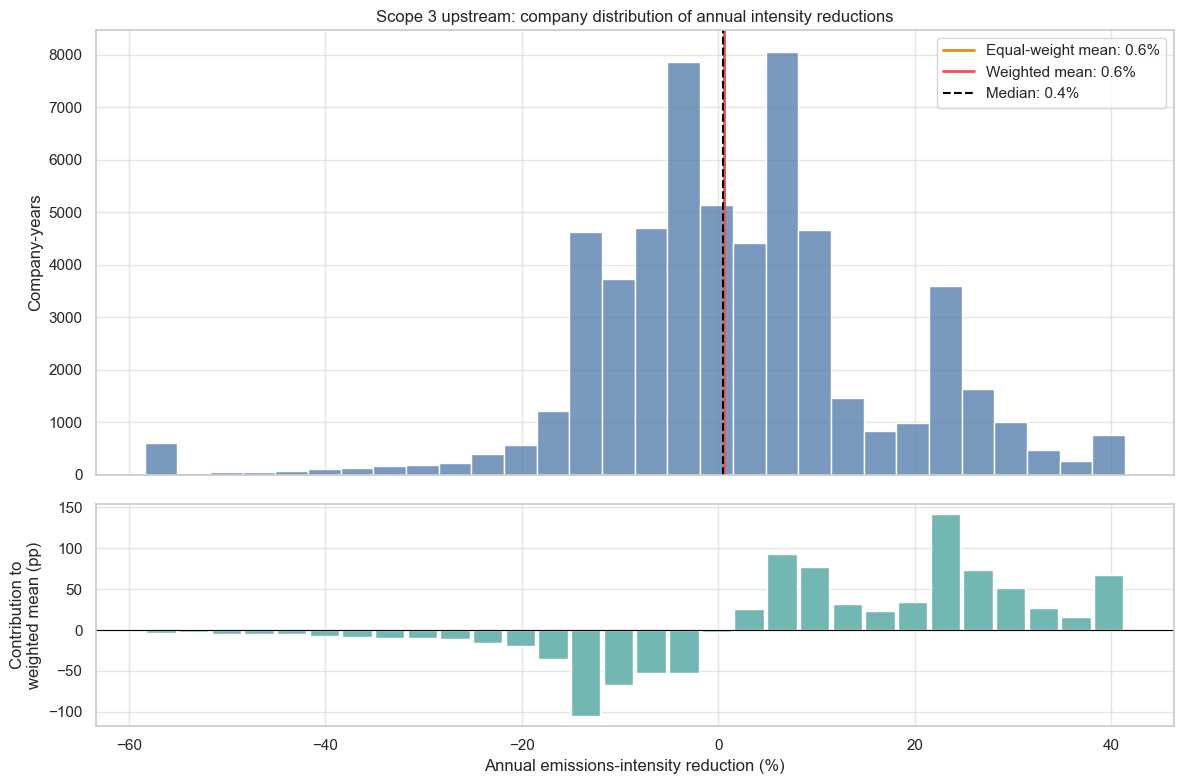

In [10]:
# Example: Scope 1. Change this to another active scope if needed.
PLOT_SCOPE = "Scope 3 upstream"

# Add a meaningful weight to policy_effect_long before this plot.
# Equal-company analysis:
plot_data = policy_effect_long.query("scope == @PLOT_SCOPE").copy()
plot_data["weight"] = 1.0

# # If you merge prior-year emissions or revenue into plot_data, instead use:
# plot_data["weight"] = plot_data["previous_scope_1_emissions"]
# plot_data["weight"] = plot_data["previous_trucost_revenue"]

plot_data = plot_data.dropna(subset=["pct_reduction", "weight"])
plot_data = plot_data[plot_data["weight"].gt(0)].copy()

# Limit the visual range only; retain the untrimmed data for reported statistics.
lower, upper = plot_data["pct_reduction"].quantile([0.01, 0.99])
plot_data["plot_reduction"] = plot_data["pct_reduction"].clip(lower, upper)

bins = np.linspace(lower, upper, 31)
plot_data["reduction_bin"] = pd.cut(plot_data["plot_reduction"], bins=bins)

bin_summary = (
    plot_data.groupby("reduction_bin", observed=True)
    .agg(
        companies=(COMPANY_ID, "nunique"),
        weighted_reduction_sum=("pct_reduction", lambda x: np.sum(
            x * plot_data.loc[x.index, "weight"]
        )),
        weight=("weight", "sum"),
    )
    .reset_index()
)

overall_weight = plot_data["weight"].sum()
bin_summary["contribution_to_weighted_mean"] = (
    100 * bin_summary["weighted_reduction_sum"] / overall_weight
)
bin_summary["bin_midpoint"] = bin_summary["reduction_bin"].apply(
    lambda interval: interval.mid
)

equal_mean = plot_data["pct_reduction"].mean()
weighted_mean = np.average(plot_data["pct_reduction"], weights=plot_data["weight"])
median = plot_data["pct_reduction"].median()

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
    facecolor="white",
)

axes[0].set_facecolor("white")
sns.histplot(
    plot_data, x="plot_reduction", bins=bins,
    color="#4c78a8", edgecolor="white", ax=axes[0],
)
axes[0].axvline(equal_mean, color="#f58518", linewidth=2, label=f"Equal-weight mean: {equal_mean:.1f}%")
axes[0].axvline(weighted_mean, color="#e45756", linewidth=2, label=f"Weighted mean: {weighted_mean:.1f}%")
axes[0].axvline(median, color="black", linestyle="--", label=f"Median: {median:.1f}%")
axes[0].set_ylabel("Company-years")
axes[0].set_title(f"{PLOT_SCOPE}: company distribution of annual intensity reductions")
axes[0].legend()

axes[1].set_facecolor("white")
axes[1].bar(
    bin_summary["bin_midpoint"],
    bin_summary["contribution_to_weighted_mean"],
    width=np.diff(bins).mean() * 0.9,
    color="#72b7b2",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Annual emissions-intensity reduction (%)")
axes[1].set_ylabel("Contribution to\nweighted mean (pp)")
fig.savefig("Scope3.pdf")
plt.tight_layout()
plt.show()

### Policy-category descriptive heatmaps


In [11]:
# Use only categories with at least one available LSEG field.
CATEGORY_ORDER = list(AVAILABLE_POLICY_CATEGORIES)
SCOPE_ORDER = sorted(policy_category_lag_summary["scope"].dropna().unique())
# Lag 0 is mechanically zero because the adoption year is the baseline.
LAG_ORDER = [1, 2, 3]

def plot_policy_category_heatmaps(metric, cmap, colorbar_label, filename, center=None, sector=None):
    """Plot all sectors pooled (default) or one exact FactSet sector."""
    if "SECTOR_DESC" not in policy_category_lag_summary.columns:
        raise RuntimeError(
            "Sector-level summaries are not in memory. Rerun the full policy-lag analysis "
            "cell first, then rerun this plotting cell."
        )
    available_sectors = sorted(policy_category_lag_summary["SECTOR_DESC"].dropna().unique())
    selected_sector = "All sectors" if sector is None else sector
    if selected_sector not in available_sectors:
        raise ValueError(
            f"Unknown sector: {selected_sector}. Choose one of: {available_sectors}"
        )
    plot_summary = policy_category_lag_summary.loc[
        policy_category_lag_summary["SECTOR_DESC"].eq(selected_sector)
    ].copy()

    figure, axes = plt.subplots(
        len(LAG_ORDER), len(SCOPE_ORDER),
        figsize=(6.4 * len(SCOPE_ORDER), max(14, 1.9 * len(CATEGORY_ORDER) + 2.5)),
        squeeze=False,
        facecolor="white",
    )

    values = plot_summary[metric].dropna()
    if center is not None:
        maximum = max(values.abs().quantile(0.95), 1)
        vmin, vmax = -maximum, maximum
    else:
        vmin, vmax = 0, 100

    for row, event_lag in enumerate(LAG_ORDER):
        for column, scope in enumerate(SCOPE_ORDER):
            ax = axes[row, column]
            ax.set_facecolor("white")

            subset = plot_summary.loc[
                plot_summary["policy_event_lag"].eq(event_lag)
                & plot_summary["scope"].eq(scope)
            ]

            matrix = (
                subset.pivot(
                    index="policy_category",
                    columns="policy_adoption_group",
                    values=metric,
                )
                .reindex(index=CATEGORY_ORDER, columns=POLICY_GROUPS)
            )
            company_counts = (
                subset.pivot(
                    index="policy_category",
                    columns="policy_adoption_group",
                    values="companies",
                )
                .reindex(index=CATEGORY_ORDER, columns=POLICY_GROUPS)
            )

            annotations = matrix.copy().astype(object)
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    value = matrix.iloc[i, j]
                    n_companies = company_counts.iloc[i, j]
                    annotations.iloc[i, j] = (
                        "" if pd.isna(value)
                        else f"{value:.1f}\n(n={int(n_companies):,})"
                    )

            sns.heatmap(
                matrix,
                cmap=cmap,
                center=center,
                vmin=vmin,
                vmax=vmax,
                annot=annotations,
                fmt="",
                linewidths=0.7,
                linecolor="white",
                cbar=row == 0 and column == len(SCOPE_ORDER) - 1,
                cbar_kws={"label": colorbar_label},
                annot_kws={"fontsize": 7.5},
                ax=ax,
            )

            ax.set_title(
                f"{scope} | {selected_sector} | {event_lag}-year lag",
                color="black", fontsize=11, fontweight="semibold", pad=10,
            )
            ax.set_xlabel("New policies adopted", color="black", fontsize=10)
            ax.set_ylabel("Policy category" if column == 0 else "", color="black", fontsize=10)
            ax.set_xticklabels(matrix.columns, rotation=0, color="black")
            ax.set_yticklabels(matrix.index, rotation=0, ha="right", color="black")
            ax.tick_params(axis="both", colors="black", labelsize=9)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("black")

    # figure.suptitle(
    #     f"Policy-category relationship with emissions-intensity outcomes: {colorbar_label}",
    #     y=1.01,
    # )
    figure.suptitle(
        f"Policy-category outcomes by adoption count: {colorbar_label}",
        color="black", fontsize=14, fontweight="semibold", y=0.995,
    )
    plt.tight_layout(rect=[0.06, 0.03, 0.98, 0.975])
    filename_path = Path(filename)
    if sector is not None:
        sector_suffix = "_".join(selected_sector.lower().replace("-", " ").split())
        filename_path = filename_path.with_name(f"{filename_path.stem}_{sector_suffix}{filename_path.suffix}")
    output_path = OUTPUT_DIR / filename_path
    figure.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")

In [ ]:
plot_policy_category_heatmaps(
    metric="positive_or_no_change_pct",
    cmap="YlGnBu",
    colorbar_label="Companies with positive or unchanged intensity reduction (%)",
    filename="policy_category_positive_reduction_share_heatmap.pdf",
    sector=None,
)


### Policy-category fixed-effects model

Firm and adoption-year effects with company-clustered standard errors.


In [ ]:
# ==========================================================================
# SCOPE 3 UPSTREAM ONLY: POLICY-LAG ANALYSIS FOR ONE TO SIX YEARS (RAW P)
# ==========================================================================
# This leaves Scope 1 and Scope 2 unchanged. It measures the cumulative
# Scope 3 upstream absolute-emissions change from policy-adoption year s to s + lag.

SCOPE3_UPSTREAM_NAME = "Scope 3 upstream"
SCOPE3_UPSTREAM_LAGS = [1, 2, 3, 4, 5, 6]
SCOPE3_UPSTREAM_REMOVE_OUTLIERS = True
SCOPE3_UPSTREAM_OUTLIER_QUANTILES = (0.01, 0.99)
def fe_significance_stars(q_value):
    if pd.isna(q_value):
        return ""
    if q_value < 0.001:
        return "***"
    if q_value < 0.01:
        return "**"
    if q_value < 0.05:
        return "*"
    if q_value < FDR_DISCOVERY_LEVEL:
        return "~"
    return ""

def fe_p_value_label(p_value):
    if pd.isna(p_value):
        return ""
    return "p<0.001" if p_value < 0.001 else f"p={p_value:.3f}"

def fit_policy_category_fe_model(data, count_column, compared_column, baseline_column):
    """Firm-FE OLS with adoption-year FE and company-clustered standard errors."""
    model_data = data[[
        COMPANY_ID, "policy_adoption_year", "outcome_year_intensity",
        baseline_column, count_column, compared_column,
    ]].copy()
    model_data = model_data.rename(columns={
        baseline_column: "baseline_intensity",
        count_column: "new_policy_count",
        compared_column: "policy_fields_compared",
    })
    model_data = model_data.loc[
        model_data["outcome_year_intensity"].gt(0)
        & model_data["baseline_intensity"].gt(0)
    ].dropna()
    model_data["log_reduction"] = (
        np.log(model_data["baseline_intensity"])
        - np.log(model_data["outcome_year_intensity"])
    )
    model_data["log_baseline_intensity"] = np.log(model_data["baseline_intensity"])

    # Firms observed only once cannot identify a within-firm effect.
    within_firm = model_data.groupby(COMPANY_ID)["new_policy_count"].transform("nunique").gt(1)
    model_data = model_data.loc[within_firm].copy()
    if len(model_data) < 20 or model_data[COMPANY_ID].nunique() < 5:
        return None, model_data

    adoption_year_fe = pd.get_dummies(
        model_data["policy_adoption_year"], prefix="adoption_year", drop_first=True, dtype=float
    )
    regressors = pd.concat([
        model_data[["new_policy_count", "policy_fields_compared", "log_baseline_intensity"]],
        adoption_year_fe,
    ], axis=1).astype(float)

    # Demeaning implements company fixed effects without creating thousands of
    # dense company-dummy columns, which keeps the notebook memory-safe.
    groups = model_data[COMPANY_ID]
    y = model_data["log_reduction"] - model_data.groupby(COMPANY_ID)["log_reduction"].transform("mean")
    X = regressors - regressors.groupby(groups).transform("mean")
    retained_columns = X.columns[X.std().gt(1e-12)]
    X = X[retained_columns]
    if "new_policy_count" not in X.columns:
        return None, model_data
    fitted = sm.OLS(y, X, missing="drop").fit(
        cov_type="cluster",
        cov_kwds={"groups": groups, "use_correction": True},
    )
    return fitted, model_data

def scope3_policy_marker(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    if p_value < 0.10:
        return "~"
    return ""


In [ ]:
# Inferential analysis: company fixed effects remove all time-invariant company
# differences (e.g., industry position or persistent reporting style). Adoption-year
# fixed effects remove shocks common to each policy-adoption cohort. Standard errors
# are clustered by company, so repeated company events are not treated as independent.
# The outcome is the cumulative *log* intensity reduction from the adoption year to
# adoption year + lag. Positive coefficients therefore indicate greater reductions.
import statsmodels.api as sm

PANEL_LAGS = [1, 2, 3]
# Interpret q < 0.10 as suggestive evidence after FDR correction. The figure
# The figure reports adjusted values separately from conventional p-value stars.
FDR_DISCOVERY_LEVEL = 0.050
# Set an exact FactSet sector here (e.g., "Electronic Technology") for a
# focal-sector model; None pools all sectors.
PANEL_SECTOR = None #"Electronic Technology" # "Producer Manufacturing" #
PANEL_RESULTS = []

for event_lag in PANEL_LAGS:
    baseline_column = f"policy_year_intensity_lag{event_lag}"
    outcome_column = f"policy_year_pct_reduction_lag{event_lag}"
    for policy_category in CATEGORY_ORDER:
        prefix = POLICY_CATEGORY_PREFIX[policy_category]
        count_column = f"{prefix}_new_policy_count_lag{event_lag}"
        compared_column = f"{prefix}_policies_compared_lag{event_lag}"
        panel_data = policy_effect_long if PANEL_SECTOR is None else policy_effect_long.loc[
            policy_effect_long["SECTOR_DESC"].eq(PANEL_SECTOR)
        ]
        for scope, scope_data in panel_data.groupby("scope"):
            event_data = scope_data.loc[
                scope_data[outcome_column].notna()
                & (~scope_data[f"{outcome_column}_is_outlier"] | (not REMOVE_POLICY_EVENT_OUTLIERS))
                & scope_data[compared_column].gt(0)
                & scope_data[count_column].notna()
            ].copy()
            event_data["policy_adoption_year"] = event_data["year"] - event_lag
            fitted, model_data = fit_policy_category_fe_model(
                event_data, count_column, compared_column, baseline_column
            )
            coefficient = np.nan if fitted is None else fitted.params.get("new_policy_count", np.nan)
            PANEL_RESULTS.append({
                "scope": scope,
                "policy_category": policy_category,
                "policy_event_lag": event_lag,
                "observations": len(model_data),
                "companies": model_data[COMPANY_ID].nunique(),
                "coefficient_log_reduction": coefficient,
                "implied_pct_effect": 100 * (np.exp(coefficient) - 1) if pd.notna(coefficient) else np.nan,
                "std_error": np.nan if fitted is None else fitted.bse.get("new_policy_count", np.nan),
                "p_value": np.nan if fitted is None else fitted.pvalues.get("new_policy_count", np.nan),
                "within_r_squared": np.nan if fitted is None else fitted.rsquared,
            })

policy_category_fe_results = pd.DataFrame(PANEL_RESULTS)

from statsmodels.stats.multitest import multipletests

# Benjamini--Hochberg correction across every category x scope x lag test in
# this heatmap. p_value_fdr is the adjusted p-value (q-value); fdr_reject
# records whether it passes the configured FDR discovery threshold.
policy_category_fe_results["p_value_fdr"] = np.nan
policy_category_fe_results["fdr_reject"] = False
valid_p_values = policy_category_fe_results["p_value"].dropna()
if not valid_p_values.empty:
    reject, pvals_corrected, _, _ = multipletests(
        valid_p_values.to_numpy(), alpha=FDR_DISCOVERY_LEVEL, method="fdr_bh"
    )
    policy_category_fe_results.loc[valid_p_values.index, "p_value_fdr"] = pvals_corrected
    policy_category_fe_results.loc[valid_p_values.index, "fdr_reject"] = reject
#display(policy_category_fe_results.sort_values(["scope", "policy_event_lag", "policy_category"]))

def plot_policy_category_fe_heatmap(filename="policy_category_firm_fe_significance.pdf"):
    """Heatmap of firm-FE policy effects; cells report implied effect, p-value, and N."""
    scopes = sorted(policy_category_fe_results["scope"].dropna().unique())
    effects = policy_category_fe_results["implied_pct_effect"].dropna()
    maximum = max(effects.abs().quantile(0.95), 1) if not effects.empty else 1
    # Give each 4-by-3 heatmap enough physical space for its two-line labels.
    fig, axes = plt.subplots(1, len(scopes), figsize=(6.4 * len(scopes), 6.2),
                             squeeze=False, facecolor="white")
    for column, scope in enumerate(scopes):
        ax = axes[0, column]
        subset = policy_category_fe_results.loc[policy_category_fe_results["scope"].eq(scope)]
        effect = subset.pivot(index="policy_category", columns="policy_event_lag", values="implied_pct_effect").reindex(
            index=CATEGORY_ORDER, columns=PANEL_LAGS
        )
        q_values = subset.pivot(index="policy_category", columns="policy_event_lag", values="p_value_fdr").reindex(
            index=CATEGORY_ORDER, columns=PANEL_LAGS
        )
        p_values = subset.pivot(index="policy_category", columns="policy_event_lag", values="p_value").reindex(
            index=CATEGORY_ORDER, columns=PANEL_LAGS
        )
        counts = subset.pivot(index="policy_category", columns="policy_event_lag", values="observations").reindex(
            index=CATEGORY_ORDER, columns=PANEL_LAGS
        )
        annotations = effect.copy().astype(object)
        for row in range(effect.shape[0]):
            for lag_column in range(effect.shape[1]):
                value, p_value, q_value, n_obs = effect.iloc[row, lag_column],  p_values.iloc[row, lag_column], q_values.iloc[row, lag_column], counts.iloc[row, lag_column]
                annotations.iloc[row, lag_column] = "" if pd.isna(value) else (
                    f"{value:+.1f}%{fe_significance_stars(p_value)} \n p={p_value:.3f} \n n={int(n_obs):,}"
                )
        sns.heatmap(
            effect, cmap="RdBu_r", center=0, vmin=-maximum, vmax=maximum,
            annot=annotations, fmt="", annot_kws={"fontsize": 11, "fontweight": "semibold"},
            linewidths=0.7, linecolor="white",
            cbar=column == len(scopes) - 1,
            cbar_kws={"label": "Estimated cumulative intensity effect (%) per additional policy"},
            ax=ax,
        )
        ax.set_title(scope, fontsize=12, fontweight="semibold", pad=10, color="black")
        ax.set_xlabel("Years after policy-adoption year", fontsize=10, color="black")
        ax.set_ylabel("Policy category" if column == 0 else "", fontsize=10, color="black")
        ax.set_xticklabels(effect.columns, rotation=0, color="black")
        ax.set_yticklabels(effect.index, rotation=0, ha="right", color="black")
        ax.tick_params(axis="both", labelsize=9, colors="black")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
    model_label = "All sectors" if PANEL_SECTOR is None else PANEL_SECTOR
    fig.suptitle(f"Policy-category effects on cumulative intensity reduction: {model_label}", y=1.03, color="black")
    fig.text(0.5, -0.06, "Firm fixed effects and adoption-year fixed effects; standard errors clustered by company. p-values use Benjamini--Hochberg FDR adjustment. ~ p<0.10; * p<0.05; ** p<0.01; *** p<0.001.", ha="center", color="black")
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    output_path = OUTPUT_DIR / filename
    fig.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")


filename = "policy_category_firm_fe_significance.pdf"
plot_policy_category_fe_heatmap(filename)


In [ ]:
plot_policy_category_heatmaps(
    metric="median_pct_reduction",
    cmap="RdBu_r",
    center=0,
    colorbar_label="Median emissions-intensity reduction (%)",
    filename="policy_category_median_reduction_heatmap.pdf",
    sector=None,
)

### Unadjusted category-correlation heatmap


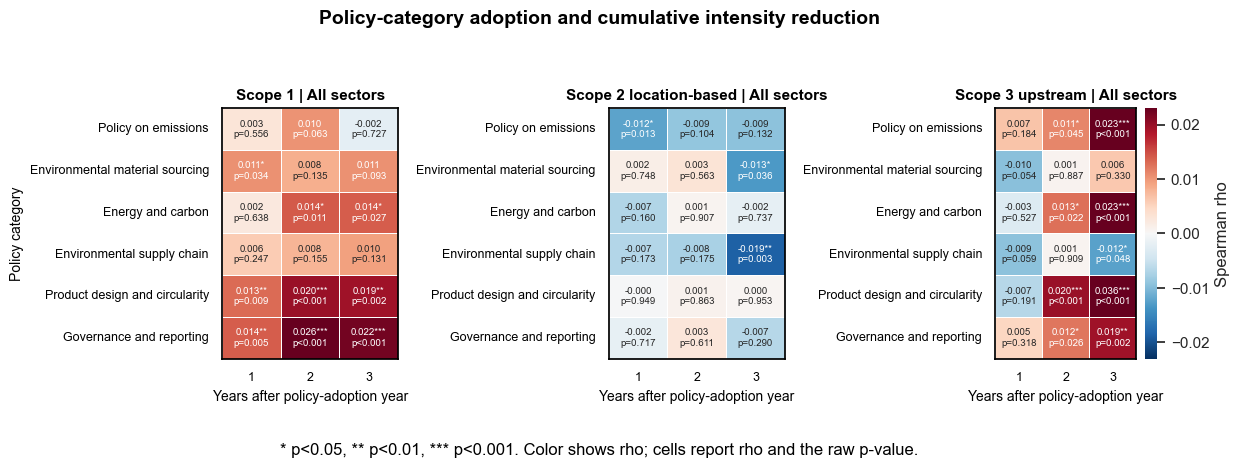

Saved: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\scope_emissions_intensity\policy_category_reduction_spearman_significance.pdf


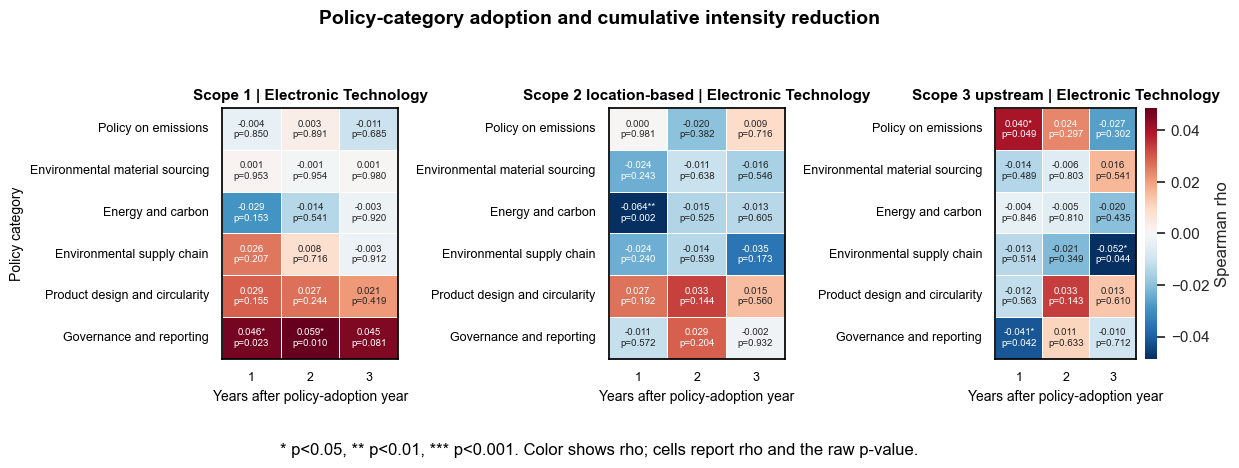

Saved: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\scope_emissions_intensity\electronic_technology_policy_significance_electronic_technology.pdf


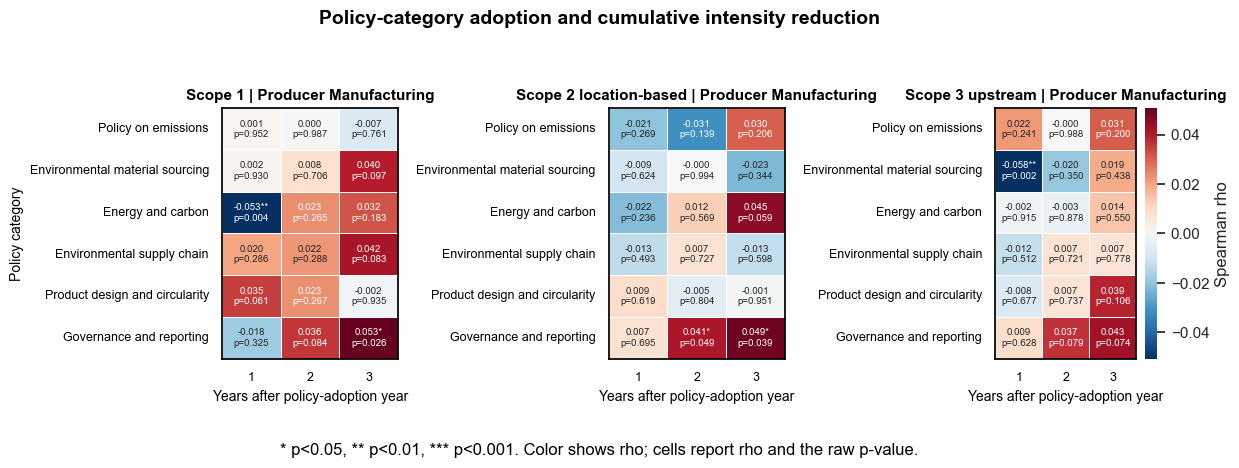

Saved: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code\data\outputs\scope_emissions_intensity\producer_manufacturing_policy_significance_producer_manufacturing.pdf


In [14]:
def significance_stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return ""

def p_value_label(p_value):
    if pd.isna(p_value):
        return ""
    return "p<0.001" if p_value < 0.001 else f"p={p_value:.3f}"

def plot_policy_category_significance_heatmap(filename, sector=None):
    """Show Spearman rho and its p-value for category adoption versus reduction."""
    required = {"SECTOR_DESC", "scope", "policy_category", "policy_event_lag", "spearman_rho", "p_value"}
    missing = required.difference(policy_category_lag_correlations.columns)
    if missing:
        raise RuntimeError(
            "Rerun the full policy-lag analysis cell before plotting significance. "
            f"Missing columns: {sorted(missing)}"
        )

    selected_sector = "All sectors" if sector is None else sector
    available_sectors = sorted(policy_category_lag_correlations["SECTOR_DESC"].dropna().unique())
    if selected_sector not in available_sectors:
        raise ValueError(f"Unknown sector: {selected_sector}. Choose one of: {available_sectors}")

    plot_data = policy_category_lag_correlations.loc[
        policy_category_lag_correlations["SECTOR_DESC"].eq(selected_sector)
        & policy_category_lag_correlations["policy_event_lag"].isin([1, 2, 3])
    ].copy()
    scopes = sorted(plot_data["scope"].dropna().unique())
    maximum = max(plot_data["spearman_rho"].abs().quantile(0.95), 0.02)

    fig, axes = plt.subplots(1, len(scopes), figsize=(4.4 * len(scopes), 4.2),
                             squeeze=False, facecolor="white")
    for column, scope in enumerate(scopes):
        ax = axes[0, column]
        ax.set_facecolor("white")
        subset = plot_data.loc[plot_data["scope"].eq(scope)]
        rho = subset.pivot(index="policy_category", columns="policy_event_lag", values="spearman_rho").reindex(
            index=CATEGORY_ORDER, columns=[1, 2, 3]
        )
        p_values = subset.pivot(index="policy_category", columns="policy_event_lag", values="p_value").reindex(
            index=CATEGORY_ORDER, columns=[1, 2, 3]
        )
        annotations = rho.copy().astype(object)
        for row in range(rho.shape[0]):
            for lag_column in range(rho.shape[1]):
                coefficient = rho.iloc[row, lag_column]
                p_value = p_values.iloc[row, lag_column]
                annotations.iloc[row, lag_column] = (
                    "" if pd.isna(coefficient)
                    else f"{coefficient:.3f}{significance_stars(p_value)}\n{p_value_label(p_value)}"
                )

        sns.heatmap(
            rho, cmap="RdBu_r", center=0, vmin=-maximum, vmax=maximum,
            annot=annotations, fmt="", annot_kws={"fontsize": 7},
            linewidths=0.7, linecolor="white",
            cbar=column == len(scopes) - 1,
            cbar_kws={"label": "Spearman rho"}, ax=ax,
        )
        ax.set_title(f"{scope} | {selected_sector}", color="black", fontsize=11, fontweight="semibold")
        ax.set_xlabel("Years after policy-adoption year", color="black", fontsize=10)
        ax.set_ylabel("Policy category" if column == 0 else "", color="black", fontsize=10)
        ax.set_xticklabels(rho.columns, rotation=0, color="black")
        ax.set_yticklabels(rho.index, rotation=0, ha="right", color="black")
        ax.tick_params(axis="both", colors="black", labelsize=9)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")

    #fig.suptitle("Policy-category adoption and cumulative intensity reduction", y=1.02)
    fig.suptitle("Policy-category adoption and cumulative intensity reduction", color="black", fontsize=14, fontweight="semibold", y=1.02)
    fig.text(0.5, -0.04, "* p<0.05, ** p<0.01, *** p<0.001. Color shows rho; cells report rho and the raw p-value.", ha="center", color="black")
    plt.tight_layout(rect=[0.04, 0.04, 0.98, 0.96])
    output_file = Path(filename)
    if sector is not None:
        sector_suffix = "_".join(selected_sector.lower().replace("-", " ").split())
        output_file = output_file.with_name(f"{output_file.stem}_{sector_suffix}{output_file.suffix}")
    output_path = OUTPUT_DIR / output_file
    fig.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output_path}")

plot_policy_category_significance_heatmap(
    filename="policy_category_reduction_spearman_significance.pdf",
    sector=None,
)
plot_policy_category_significance_heatmap(
    filename="electronic_technology_policy_significance.pdf",
    sector="Electronic Technology",
)
plot_policy_category_significance_heatmap(
    filename="producer_manufacturing_policy_significance.pdf",
    sector="Producer Manufacturing",
)

## 7. Scope 3 upstream absolute emissions: one- to six-year lags

This extension uses absolute tCO2e, not revenue intensity, and reports raw clustered p-values.


### Build Scope 3 upstream adoption-year comparisons


In [ ]:
if SCOPE3_UPSTREAM_NAME not in SCOPE_COLUMNS:
    raise KeyError(f"{SCOPE3_UPSTREAM_NAME!r} is not active in SCOPE_COLUMNS.")

scope3_emissions_column = SCOPE_COLUMNS[SCOPE3_UPSTREAM_NAME]
scope3_levels = base[[COMPANY_ID, "year", scope3_emissions_column]].copy()
# This compatibility-named column stores absolute tCO2e, not an intensity.
scope3_levels["outcome_year_intensity"] = pd.to_numeric(
    scope3_levels[scope3_emissions_column], errors="coerce"
)
scope3_levels = scope3_levels[[COMPANY_ID, "year", "outcome_year_intensity"]]

if scope3_levels.duplicated([COMPANY_ID, "year"]).any():
    raise ValueError("Scope 3 upstream absolute emissions have duplicate company-year records.")

scope3_lag_panel = reduction_panel[["year", COMPANY_ID, "SECTOR_DESC"]].copy()
scope3_lag_panel = scope3_lag_panel.merge(
    scope3_levels, on=[COMPANY_ID, "year"], how="left", validate="one_to_one"
)

scope3_category_event_columns = [
    f"{POLICY_CATEGORY_PREFIX[category]}_{suffix}"
    for category in AVAILABLE_POLICY_CATEGORIES
    for suffix in ["new_policy_count", "policies_compared"]
]

for event_lag in SCOPE3_UPSTREAM_LAGS:
    lagged_events = policy_events[
        [COMPANY_ID, "year", *scope3_category_event_columns]
    ].copy()
    lagged_events["year"] += event_lag
    lagged_events = lagged_events.rename(columns={
        column: f"{column}_lag{event_lag}"
        for column in scope3_category_event_columns
    })
    scope3_lag_panel = scope3_lag_panel.merge(
        lagged_events, on=[COMPANY_ID, "year"], how="left", validate="one_to_one"
    )

    adoption_levels = scope3_levels.rename(
        columns={"outcome_year_intensity": f"baseline_intensity_lag{event_lag}"}
    ).copy()
    adoption_levels["year"] += event_lag
    scope3_lag_panel = scope3_lag_panel.merge(
        adoption_levels, on=[COMPANY_ID, "year"], how="left", validate="one_to_one"
    )

    baseline_column = f"baseline_intensity_lag{event_lag}"
    outcome_column = f"scope3_upstream_absolute_pct_reduction_lag{event_lag}"
    valid_pair = (
        scope3_lag_panel["outcome_year_intensity"].ge(0)
        & scope3_lag_panel[baseline_column].gt(0)
    )
    scope3_lag_panel[outcome_column] = 100 * (
        1
        - scope3_lag_panel["outcome_year_intensity"].where(valid_pair)
        / scope3_lag_panel[baseline_column].where(valid_pair)
    )

    lower, upper = scope3_lag_panel[outcome_column].quantile(
        SCOPE3_UPSTREAM_OUTLIER_QUANTILES
    )
    outlier_column = f"{outcome_column}_is_outlier"
    scope3_lag_panel[outlier_column] = (
        scope3_lag_panel[outcome_column].notna()
        & (
            scope3_lag_panel[outcome_column].lt(lower)
            | scope3_lag_panel[outcome_column].gt(upper)
        )
    )

scope3_upstream_outlier_summary = pd.DataFrame([
    {
        "lag": lag,
        "lower_bound": scope3_lag_panel[
            f"scope3_upstream_absolute_pct_reduction_lag{lag}"
        ].quantile(SCOPE3_UPSTREAM_OUTLIER_QUANTILES[0]),
        "upper_bound": scope3_lag_panel[
            f"scope3_upstream_absolute_pct_reduction_lag{lag}"
        ].quantile(SCOPE3_UPSTREAM_OUTLIER_QUANTILES[1]),
        "observations_before": scope3_lag_panel[
            f"scope3_upstream_absolute_pct_reduction_lag{lag}"
        ].notna().sum(),
        "observations_removed": scope3_lag_panel[
            f"scope3_upstream_absolute_pct_reduction_lag{lag}_is_outlier"
        ].sum(),
    }
    for lag in SCOPE3_UPSTREAM_LAGS
])
scope3_upstream_outlier_summary["observations_after"] = (
    scope3_upstream_outlier_summary["observations_before"]
    - scope3_upstream_outlier_summary["observations_removed"]
)
display(scope3_upstream_outlier_summary)


### Estimate category associations by lag


In [ ]:
scope3_upstream_policy_results = []
for event_lag in SCOPE3_UPSTREAM_LAGS:
    outcome_column = f"scope3_upstream_absolute_pct_reduction_lag{event_lag}"
    baseline_column = f"baseline_intensity_lag{event_lag}"
    outlier_column = f"{outcome_column}_is_outlier"

    for category, fields in AVAILABLE_POLICY_CATEGORIES.items():
        prefix = POLICY_CATEGORY_PREFIX[category]
        count_column = f"{prefix}_new_policy_count_lag{event_lag}"
        compared_column = f"{prefix}_policies_compared_lag{event_lag}"

        event_data = scope3_lag_panel.loc[
            scope3_lag_panel[outcome_column].notna()
            & (
                ~scope3_lag_panel[outlier_column]
                | (not SCOPE3_UPSTREAM_REMOVE_OUTLIERS)
            )
            & scope3_lag_panel[compared_column].gt(0)
            & scope3_lag_panel[count_column].notna()
        ].copy()
        event_data["policy_adoption_year"] = event_data["year"] - event_lag

        fitted, model_data = fit_policy_category_fe_model(
            event_data, count_column, compared_column, baseline_column
        )
        beta = np.nan if fitted is None else fitted.params.get("new_policy_count", np.nan)
        p_value = np.nan if fitted is None else fitted.pvalues.get("new_policy_count", np.nan)

        scope3_upstream_policy_results.append({
            "policy_category": category,
            "outcome_basis": "absolute emissions",
            "policy_event_lag": event_lag,
            "observations": len(model_data),
            "companies": model_data[COMPANY_ID].nunique(),
            "implied_pct_effect": (
                100 * (np.exp(beta) - 1) if pd.notna(beta) else np.nan
            ),
            "std_error": (
                np.nan if fitted is None
                else fitted.bse.get("new_policy_count", np.nan)
            ),
            "p_value": p_value,
            "p_marker": scope3_policy_marker(p_value),
            "within_r_squared": np.nan if fitted is None else fitted.rsquared,
        })

scope3_upstream_policy_lag_results = pd.DataFrame(
    scope3_upstream_policy_results
).sort_values(["policy_category", "policy_event_lag"])

display(scope3_upstream_policy_lag_results)
scope3_upstream_policy_lag_results.to_csv(
    OUTPUT_DIR / "scope3_upstream_absolute_policy_lag_1_to_6_raw_pvalues.csv",
    index=False,
)


### Plot Scope 3 upstream associations


In [ ]:
# Visual: effect per additional policy in a category, with raw clustered p-values.
scope3_effect = scope3_upstream_policy_lag_results.pivot(
    index="policy_category",
    columns="policy_event_lag",
    values="implied_pct_effect",
).reindex(index=CATEGORY_ORDER, columns=SCOPE3_UPSTREAM_LAGS)

scope3_p_values = scope3_upstream_policy_lag_results.pivot(
    index="policy_category",
    columns="policy_event_lag",
    values="p_value",
).reindex(index=CATEGORY_ORDER, columns=SCOPE3_UPSTREAM_LAGS)

scope3_annotations = scope3_effect.copy().astype(object)
for row in range(scope3_effect.shape[0]):
    for column in range(scope3_effect.shape[1]):
        effect = scope3_effect.iloc[row, column]
        p_value = scope3_p_values.iloc[row, column]
        label = "" if pd.isna(p_value) else (
            "p<.001" if p_value < 0.001 else f"p={p_value:.3f}"
        )
        scope3_annotations.iloc[row, column] = "" if pd.isna(effect) else (
            f"{effect:+.1f}%{scope3_policy_marker(p_value)}\n{label}"
        )

nonmissing_scope3_effects = scope3_effect.abs().stack().dropna()
maximum = (
    max(float(nonmissing_scope3_effects.quantile(0.95)), 1)
    if not nonmissing_scope3_effects.empty else 1
)
fig, ax = plt.subplots(
    figsize=(13, max(6.5, 0.8 * len(CATEGORY_ORDER) + 2)),
    facecolor="white",
)
sns.heatmap(
    scope3_effect,
    cmap="RdBu_r",
    center=0,
    vmin=-maximum,
    vmax=maximum,
    annot=scope3_annotations,
    fmt="",
    annot_kws={"fontsize": 9},
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Estimated cumulative Scope 3 upstream absolute-emissions effect (%) per additional policy"
    },
    ax=ax,
)
ax.set_title(
    "Scope 3 upstream absolute emissions: policy-category effects one to six years after adoption",
    color="black",
    fontsize=13,
    fontweight="semibold",
    pad=12,
)
ax.set_xlabel("Years after policy-adoption year", color="black", fontsize=11)
ax.set_ylabel("Policy category", color="black", fontsize=11)
ax.set_xticklabels(scope3_effect.columns, rotation=0, color="black")
ax.set_yticklabels(scope3_effect.index, rotation=0, ha="right", color="black")
ax.tick_params(axis="both", colors="black", labelsize=10)
fig.text(
    0.5,
    -0.03,
    "Raw company-clustered p-values; ~ p<0.10; * p<0.05; ** p<0.01; *** p<0.001.",
    ha="center",
    color="black",
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
output_path = OUTPUT_DIR / "scope3_upstream_absolute_policy_lag_1_to_6_raw_pvalues.pdf"
fig.savefig(output_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {output_path}")


## 8. Individual-policy fixed-effects models

Each policy is considered separately; p-values are unadjusted.


In [ ]:
INDIVIDUAL_POLICY_LAGS = [1, 2, 3]
INDIVIDUAL_POLICY_P_VALUE_LEVEL = 0.10

INDIVIDUAL_POLICY_LABELS = {
    field: field.replace("_", " ").title()
    for field in AVAILABLE_POLICY_FIELDS
}


def individual_policy_marker(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    if p_value < INDIVIDUAL_POLICY_P_VALUE_LEVEL:
        return "~"
    return ""


# A policy adoption is a 0 -> 1 change observed in consecutive years.
individual_policy_events = policy_events[["year", COMPANY_ID]].copy()

for field in AVAILABLE_POLICY_FIELDS:
    individual_policy_events[f"{field}_adopted"] = (
        new_policy_flags[field]
        .astype(float)
        .where(policy_pair_observed[field])
    )
    individual_policy_events[f"{field}_observed"] = (
        policy_pair_observed[field].astype(float)
    )


### Align policy events and estimate lagged models


In [ ]:
# Align adoption in year s with reduction measured in year s + lag.
individual_policy_effect = policy_effect_long.copy()

individual_event_columns = [
    f"{field}_{suffix}"
    for field in AVAILABLE_POLICY_FIELDS
    for suffix in ["adopted", "observed"]
]

for event_lag in INDIVIDUAL_POLICY_LAGS:
    lagged_events = individual_policy_events[
        ["year", COMPANY_ID, *individual_event_columns]
    ].copy()

    lagged_events["year"] += event_lag
    lagged_events = lagged_events.rename(columns={
        column: f"{column}_lag{event_lag}"
        for column in individual_event_columns
    })

    individual_policy_effect = individual_policy_effect.merge(
        lagged_events,
        on=[COMPANY_ID, "year"],
        how="left",
        validate="many_to_one",
    )


individual_policy_results = []

for event_lag in INDIVIDUAL_POLICY_LAGS:
    outcome_column = f"policy_year_pct_reduction_lag{event_lag}"
    baseline_column = f"policy_year_intensity_lag{event_lag}"
    outlier_column = f"{outcome_column}_is_outlier"

    for field in AVAILABLE_POLICY_FIELDS:
        adopted_column = f"{field}_adopted_lag{event_lag}"
        observed_column = f"{field}_observed_lag{event_lag}"

        for scope, scope_data in individual_policy_effect.groupby("scope"):
            valid_outlier_mask = pd.Series(True, index=scope_data.index)

            if (
                globals().get("REMOVE_POLICY_EVENT_OUTLIERS", False)
                and outlier_column in scope_data.columns
            ):
                valid_outlier_mask = ~scope_data[outlier_column].fillna(False)

            event_data = scope_data.loc[
                scope_data[outcome_column].notna()
                & valid_outlier_mask
                & scope_data[observed_column].eq(1)
                & scope_data[adopted_column].notna()
            ].copy()

            event_data["policy_adoption_year"] = (
                event_data["year"] - event_lag
            )

            fitted, model_data = fit_policy_category_fe_model(
                event_data,
                adopted_column,
                observed_column,
                baseline_column,
            )

            beta = (
                np.nan
                if fitted is None
                else fitted.params.get("new_policy_count", np.nan)
            )
            p_value = (
                np.nan
                if fitted is None
                else fitted.pvalues.get("new_policy_count", np.nan)
            )

            individual_policy_results.append({
                "policy": field,
                "policy_label": INDIVIDUAL_POLICY_LABELS[field],
                "scope": scope,
                "policy_event_lag": event_lag,
                "observations": len(model_data),
                "companies": model_data[COMPANY_ID].nunique(),
                "implied_pct_effect": (
                    100 * (np.exp(beta) - 1)
                    if pd.notna(beta) else np.nan
                ),
                "std_error": (
                    np.nan
                    if fitted is None
                    else fitted.bse.get("new_policy_count", np.nan)
                ),
                "p_value": p_value,
                "p_marker": individual_policy_marker(p_value),
                "within_r_squared": (
                    np.nan
                    if fitted is None
                    else fitted.rsquared
                ),
            })


individual_policy_fe_results = (
    pd.DataFrame(individual_policy_results)
    .sort_values(["scope", "policy_event_lag", "policy_label"])
    .reset_index(drop=True)
)

display(individual_policy_fe_results)

individual_policy_fe_results.to_csv(
    OUTPUT_DIR / "individual_policy_fixed_effects_raw_pvalues.csv",
    index=False,
)

print(
    "Saved:",
    OUTPUT_DIR / "individual_policy_fixed_effects_raw_pvalues.csv",
)
